## Ultimate Data Science Challenge Submission
**Author:** Georgia Jenkins

**Submission Date:** 4 September 2025

In [53]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report


### Part 1 ‐ Exploratory data analysis
The attached logins.json file contains (simulated) timestamps of user logins in a particular
geographic location. Aggregate these login counts based on 15­ minute time intervals, and
visualize and describe the resulting time series of login counts in ways that best characterize the
underlying patterns of the demand. Please report/illustrate important features of the demand,
such as daily cycles. If there are data quality issues, please report them.

In [54]:
# Read in logins.json file as logins
logins = pd.read_json("logins.json")
logins.head()

,login_time
0,1970-01-01 20:13:18
1,1970-01-01 20:16:10
2,1970-01-01 20:16:37
3,1970-01-01 20:16:36
4,1970-01-01 20:26:21


In [55]:
# Inspect the logins data
logins.describe()

,login_time
count,93142
mean,1970-02-26 19:09:39.779648278
min,1970-01-01 20:12:16
25%,1970-02-04 10:37:19.750000
50%,1970-03-01 06:33:05.500000
75%,1970-03-22 04:01:10.750000
max,1970-04-13 18:57:38


In [56]:
# Check for null values
logins.isna().sum()

login_time    0
dtype: int64

array([[<Axes: title={'center': 'login_time'}>]], dtype=object)

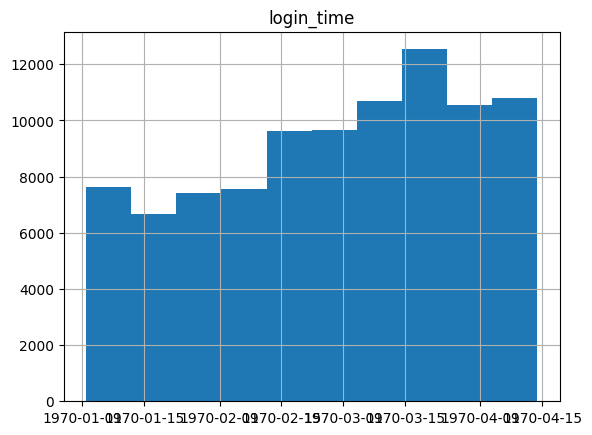

In [57]:
# Min, max, and null values look good
# Check the overall distribution of login times for any anomalies/outliers
logins.hist()

In [58]:
# Add a column we can sum to get the number of users after aggregation
logins['users'] = 1
# Set the datetime as the index
logins = logins.set_index('login_time')
logins.head()

,users
login_time,
1970-01-01 20:13:18,1
1970-01-01 20:16:10,1
1970-01-01 20:16:37,1
1970-01-01 20:16:36,1
1970-01-01 20:26:21,1


In [59]:
# Aggregate logins data into 15 minute intervals
logins_15_min = logins.resample('15T').sum()
logins_15_min.head()

/var/folders/cq/gp4mmh_532d1t3573lxjzj5w0000gp/T/ipykernel_77306/2218299891.py:2: FutureWarning: 'T' is deprecated and will be removed in a future version, please use 'min' instead.
  logins_15_min = logins.resample('15T').sum()


,users
login_time,
1970-01-01 20:00:00,2
1970-01-01 20:15:00,6
1970-01-01 20:30:00,9
1970-01-01 20:45:00,7
1970-01-01 21:00:00,1


In [60]:
# Reindex for plotting
logins_15_min = logins_15_min.reset_index()
logins_15_min.head(3)

,login_time,users
0,1970-01-01 20:00:00,2
1,1970-01-01 20:15:00,6
2,1970-01-01 20:30:00,9


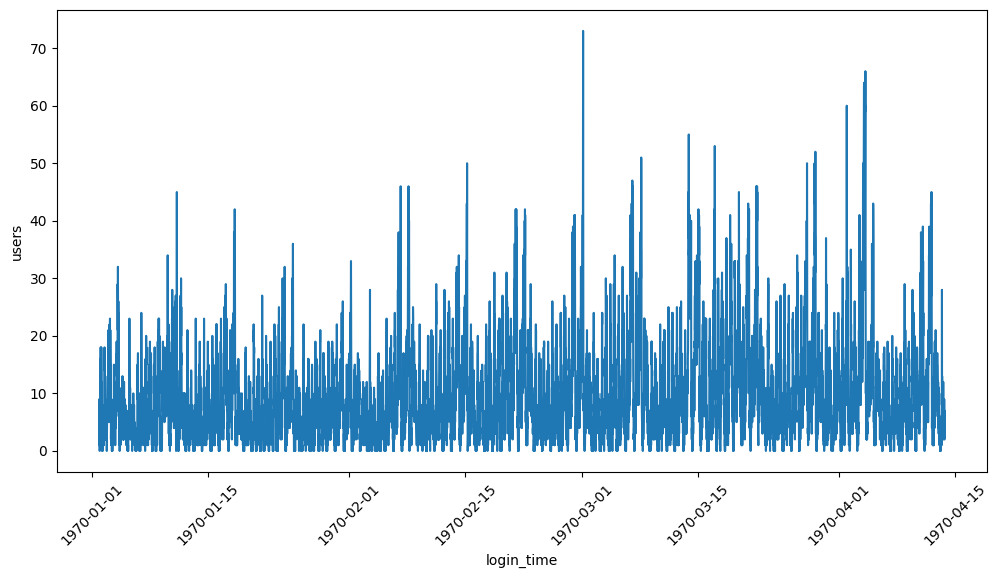

In [61]:
# Plot the aggregated login times
plt.figure(figsize=(12, 6))
sns.lineplot(data=logins_15_min, x='login_time', y='users')
plt.xticks(rotation=45)
plt.show()

In [62]:
# This is really hard to look at. Let's break it up into meaningful chunks 
logins_15_min['time_str'] = logins_15_min['login_time'].dt.strftime('%H:%M')
logins_15_min['date_str'] = logins_15_min['login_time'].dt.strftime('%Y-%m-%d')
logins_15_min.head()

,login_time,users,time_str,date_str
0,1970-01-01 20:00:00,2,20:00,1970-01-01
1,1970-01-01 20:15:00,6,20:15,1970-01-01
2,1970-01-01 20:30:00,9,20:30,1970-01-01
3,1970-01-01 20:45:00,7,20:45,1970-01-01
4,1970-01-01 21:00:00,1,21:00,1970-01-01


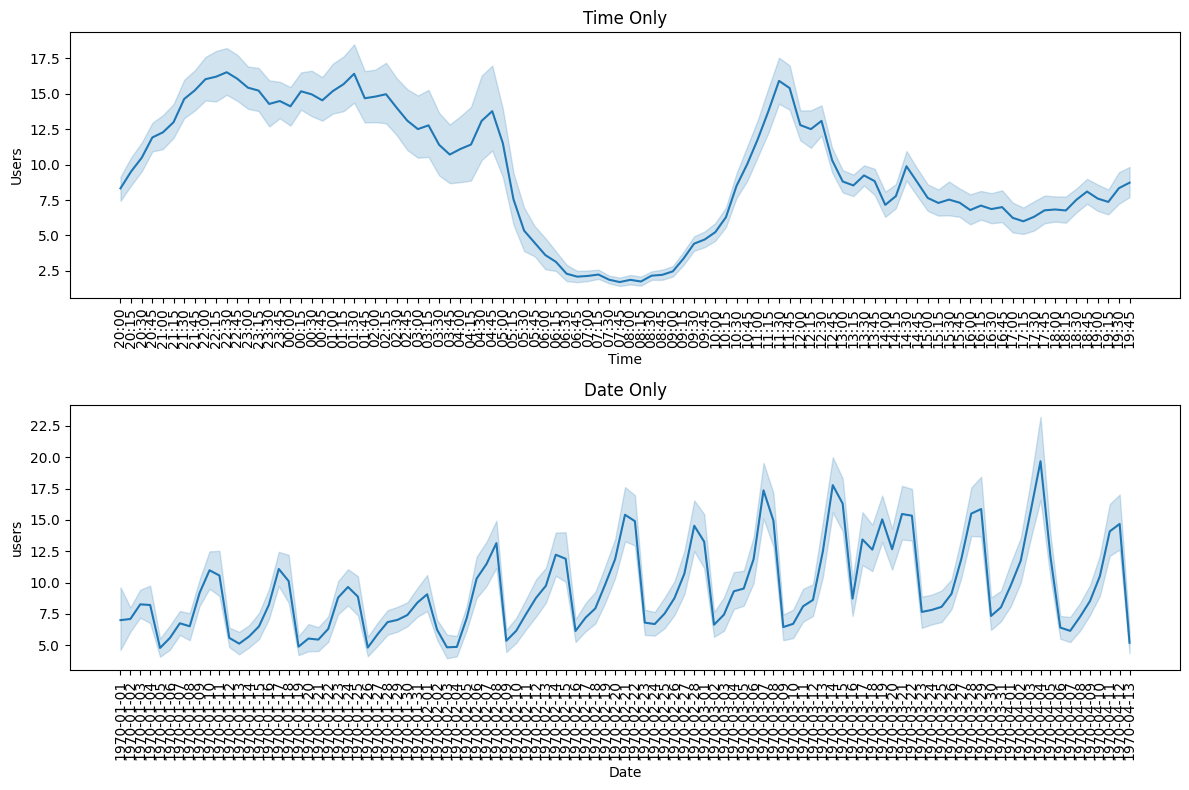

In [63]:
# First, let's see if there is a trend based on time or date only
fig, axes = plt.subplots(2, 1, figsize=(12, 8), sharex=False)

# First time series plot
sns.lineplot(data=logins_15_min, x='time_str', y='users', ax=axes[0])
axes[0].set_title('Time Only')
axes[0].set_xlabel('Time')
axes[0].set_ylabel('Users')
axes[0].tick_params(axis='x', rotation=90)

# Second time series plot
sns.lineplot(data=logins_15_min, x='date_str', y='users', ax=axes[1])
axes[1].set_title('Date Only')
axes[1].set_xlabel('Date')
axes[1].tick_params(axis='x', rotation=90)

# Adjust layout
plt.tight_layout()
plt.show()

**TIMES**

There is a huge dip in logins starting around 4:45 AM. Logins sharply decline till 6:30 AM, then quickly shoot up around 9 AM. The peak at 11:15 AM, then drop a little and plateau until another increase starting at 8PM. The most logins appear between 10PM and 1:30PM. 

**DATES** 

The mean number of logins looks fairly constant, with perhaps a gentle increase over time. We a pretty obvious flucuation week to week. Let's see which day of the week is most popular next.

In [64]:
logins_15_min['day_of_week'] = logins_15_min['login_time'].dt.day_name()
logins_15_min.head()

,login_time,users,time_str,date_str,day_of_week
0,1970-01-01 20:00:00,2,20:00,1970-01-01,Thursday
1,1970-01-01 20:15:00,6,20:15,1970-01-01,Thursday
2,1970-01-01 20:30:00,9,20:30,1970-01-01,Thursday
3,1970-01-01 20:45:00,7,20:45,1970-01-01,Thursday
4,1970-01-01 21:00:00,1,21:00,1970-01-01,Thursday


<Axes: xlabel='day_of_week'>

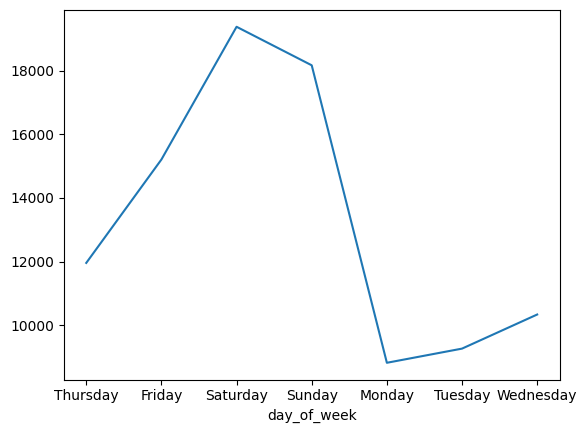

In [65]:
# Aggregate number of users by day of the week
users_by_day = (
    logins_15_min
    .groupby('day_of_week', sort=False)['users']
    .sum()
)
users_by_day.plot()

### Summary (Part 1)
**Day of the week:** Demand is highest on Saturday, with Sunday as a close second. Logins drop off considerably on Monday and gradually increase through Friday.

**Time of day:** Demand is highest at night, from 10PM until 1:30AM. Demand is very low between 4:30AM until 9AM, when logins quickly shoot up to peak at 11:30AM. Logins hold at a moderate level throughout the day, from about 1PM until 8PM where they begin to increase.  

### Part 2 ‐ Experiment and metrics design
The neighboring cities of Gotham and Metropolis have complementary circadian rhythms: on
weekdays, Ultimate Gotham is most active at night, and Ultimate Metropolis is most active
during the day. On weekends, there is reasonable activity in both cities.
However, a toll bridge, with a two way toll, between the two cities causes driver partners to tend
to be exclusive to each city. The Ultimate managers of city operations for the two cities have
proposed an experiment to encourage driver partners to be available in both cities, by
reimbursing all toll costs.
1) What would you choose as the key measure of success of this experiment in
encouraging driver partners to serve both cities, and why would you choose this metric?

**Answer:** The main goal of this change is to make more drivers available in areas with more activity, so that Ultimate can deliver more rides and make more money. If Metropolis drivers are staying in Metropolis, and Gotham drivers in Gotham, that means fewer drivers to pick up customers, which means longer wait times. Thus, we can use customer wait times to estimate whether more drivers are available in a busy area. Lower wait times after the change would indicate that more drivers are available. We're also interested in how much money this change makes for the company, and if it's worth it to pay tolls for the drivers, so we should also compare revenue before and after the change.  

2) Describe a practical experiment you would design to compare the effectiveness of the
proposed change in relation to the key measure of success. Please provide details on:

    a) how you will implement the experiment
    
    b) what statistical test(s) you will conduct to verify the significance of the
observation

    c) how you would interpret the results and provide recommendations to the city
operations team along with any caveats.

**Answer:** We will designate two comparison periods: 1) the 6 months before the toll reimbursement policy 2) the 6 months after the policy goes into effect. We will calculate the average wait times and the total revenue collect during each of those periods, then run a comparison of means t-test on each metric. Results will be interpreted and recommendations made as follows:
1) Revenue significantly increases, wait times significantly decrease: the policy change was a success and is worth the money
2) Revenue does not significantly increase, wait times significantly decrease: the policy change had the desired effect on driver activity, but it might not be worth reimbursing the cost of tolls
3) Revenue does not significantly increase, wait times do not significantly decrease: the policy change was not successful, and the policy change is not worth reimbursing the cost of tolls
4) Revenue significantly increases, but wait times do not significantly decrease: this would be surprising and would be cause for additional research into why the revenue changed

Caveats: during the 2 study periods, we will need to log any events outside of our control that could influence rider/driver activity. For example, major construction in busy areas, extreme weather events, political unrest, etc. 

*Note: The two cities of Gotham and Metropolis are not in the provided dataset; however, you do
not need this information to answer Part 2.*

### Part 3 ‐ Predictive modeling
Ultimate is interested in predicting rider retention. To help explore this question, we have
provided a sample dataset of a cohort of users who signed up for an Ultimate account in
January 2014. The data was pulled several months later; we consider a user retained if they
were “active” (i.e. took a trip) in the preceding 30 days.

We would like you to use this data set to help understand what factors are the best predictors
for retention, and offer suggestions to operationalize those insights to help Ultimate.
The data is in the attached file ultimate_data_challenge.json. See below for a detailed
description of the dataset. Please include any code you wrote for the analysis and delete the
dataset when you have finished with the challenge.

1) Perform any cleaning, exploratory analysis, and/or visualizations to use the provided
data for this analysis (a few sentences/plots describing your approach will suffice). What
fraction of the observed users were retained?

2) Build a predictive model to help Ultimate determine whether or not a user will be active in
their 6th month on the system. Discuss why you chose your approach, what alternatives
you considered, and any concerns you have. How valid is your model? Include any key
indicators of model performance.

3) Briefly discuss how Ultimate might leverage the insights gained from the model to
improve its long term rider retention (again, a few sentences will suffice).

In [66]:
# Read in ultimate_data_challenge.json file as ultimate_data
ultimate_data = pd.read_json("ultimate_data_challenge.json")
ultimate_data.head()

,city,trips_in_first_30_days,signup_date,avg_rating_of_driver,avg_surge,last_trip_date,phone,surge_pct,ultimate_black_user,weekday_pct,avg_dist,avg_rating_by_driver
0,King's Landing,4,2014-01-25,4.7,1.10,2014-06-17,iPhone,15.4,True,46.2,3.67,5.0
1,Astapor,0,2014-01-29,5.0,1.00,2014-05-05,Android,0.0,False,50.0,8.26,5.0
2,Astapor,3,2014-01-06,4.3,1.00,2014-01-07,iPhone,0.0,False,100.0,0.77,5.0
3,King's Landing,9,2014-01-10,4.6,1.14,2014-06-29,iPhone,20.0,True,80.0,2.36,4.9
4,Winterfell,14,2014-01-27,4.4,1.19,2014-03-15,Android,11.8,False,82.4,3.13,4.9


In [67]:
# Put dates in datetime format
ultimate_data['last_trip_date'] = pd.to_datetime(ultimate_data['last_trip_date'])
ultimate_data['signup_date'] = pd.to_datetime(ultimate_data['signup_date'])

In [68]:
ultimate_data.describe().T

,count,mean,min,25%,50%,75%,max,std
trips_in_first_30_days,50000.0,2.2782,0.0,0.0,1.0,3.0,125.0,3.792684
signup_date,50000,2014-01-16 13:04:20.352000,2014-01-01 00:00:00,2014-01-09 00:00:00,2014-01-17 00:00:00,2014-01-24 00:00:00,2014-01-31 00:00:00,NaN
avg_rating_of_driver,41878.0,4.601559,1.0,4.3,4.9,5.0,5.0,0.617338
avg_surge,50000.0,1.074764,1.0,1.0,1.0,1.05,8.0,0.222336
last_trip_date,50000,2014-04-19 08:02:04.992000256,2014-01-01 00:00:00,2014-02-14 00:00:00,2014-05-08 00:00:00,2014-06-18 00:00:00,2014-07-01 00:00:00,NaN
surge_pct,50000.0,8.849536,0.0,0.0,0.0,8.6,100.0,19.958811
weekday_pct,50000.0,60.926084,0.0,33.3,66.7,100.0,100.0,37.081503
avg_dist,50000.0,5.796827,0.0,2.42,3.88,6.94,160.96,5.707357
avg_rating_by_driver,49799.0,4.778158,1.0,4.7,5.0,5.0,5.0,0.446652


In [69]:
from datetime import datetime, timedelta

# Estimate when the data was pulled using the maximum last_trip_date
max_trip = ultimate_data.last_trip_date.max()
start_of_period = max_trip-timedelta(days=30)

print("The period used to determine retention starts on {} and ends on {}.".format(
    start_of_period.strftime("%Y-%m-%d"), max_trip.strftime("%Y-%m-%d")))

The period used to determine retention starts on 2014-06-01 and ends on 2014-07-01.


In [70]:
# Check out null values
ultimate_data.isnull().sum()

city                         0
trips_in_first_30_days       0
signup_date                  0
avg_rating_of_driver      8122
avg_surge                    0
last_trip_date               0
phone                      396
surge_pct                    0
ultimate_black_user          0
weekday_pct                  0
avg_dist                     0
avg_rating_by_driver       201
dtype: int64

In [71]:
8122 / 50000

0.16244

We can't have null values when we're modeling, and they don't make up a huge percentage of the dataset, so we'll drop them before modeling. Leet's keep them for now though since we haven't calcuated % retained yet.

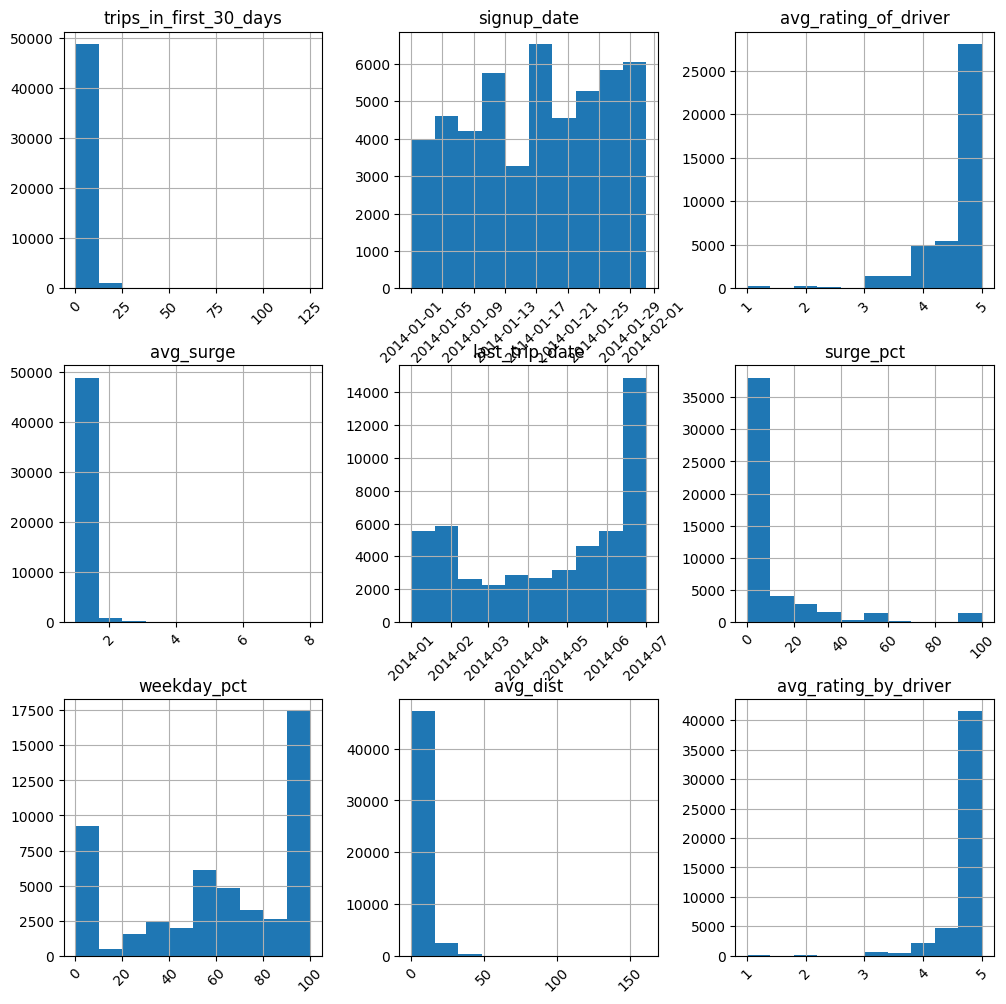

In [72]:
# Look at the distribution of each variable
ultimate_data.hist(figsize=(12,12),xrot=45);

`trips_in_first_30_days` most riders take fewer than 12.5

`signup_date` pretty uniformly distributed with a dip in the middle of the month

`avg_rating_of_driver` left skewed, most drivers have ratings above 4

`avg_surge` usually around 1

`last_trip_date` many users appear to be active in the last month, but there are a few thousand each month who stop riding 

`surge_pct` right skewed, not many trips taken with surge multiplier > 1

`weekday_pct` lots of weekday rider ship

`avg_dist` shorter trips are most common

`avg_rating_by_driver` left skewed, most riders have ratings above 4.5 (a little better than ratings of drivers)

In [73]:
# Check out categorical variables 
print('City:',ultimate_data['city'].value_counts())

print('Phone:',ultimate_data['phone'].value_counts())

print('Ultimate Black User:',ultimate_data['ultimate_black_user'].value_counts())

City: city
Winterfell        23336
Astapor           16534
King's Landing    10130
Name: count, dtype: int64
Phone: phone
iPhone     34582
Android    15022
Name: count, dtype: int64
Ultimate Black User: ultimate_black_user
False    31146
True     18854
Name: count, dtype: int64


In [74]:
# Add a column to labels riders as retained or not 
ultimate_data['retained'] = ultimate_data.last_trip_date.case_when(caselist=[
    ((ultimate_data.last_trip_date >= start_of_period), 1),
    ((ultimate_data.last_trip_date < start_of_period), 0)
])

print(ultimate_data.retained.value_counts())
print('Null values:',ultimate_data.retained.isnull().sum())

print('Retained start:',ultimate_data['last_trip_date'][ultimate_data['retained']==1].min())
print('Retained end:',ultimate_data['last_trip_date'][ultimate_data['retained']==1].max())
print('Churned start:',ultimate_data['last_trip_date'][ultimate_data['retained']==0].min())
print('Churned end:',ultimate_data['last_trip_date'][ultimate_data['retained']==0].max())

retained
0    31196
1    18804
Name: count, dtype: int64
Null values: 0
Retained start: 2014-06-01 00:00:00
Retained end: 2014-07-01 00:00:00
Churned start: 2014-01-01 00:00:00
Churned end: 2014-05-31 00:00:00


In [75]:
# What fraction of users were retained?
retained_count = ultimate_data.retained.sum()
fraction = retained_count / len(ultimate_data.retained)

print("Ultimate retained {:.0%} of riders.".format(fraction))

Ultimate retained 38% of riders.


In [76]:
# Drop rows with null values
ultimate_data = ultimate_data.dropna()
ultimate_data.isnull().sum()

city                      0
trips_in_first_30_days    0
signup_date               0
avg_rating_of_driver      0
avg_surge                 0
last_trip_date            0
phone                     0
surge_pct                 0
ultimate_black_user       0
weekday_pct               0
avg_dist                  0
avg_rating_by_driver      0
retained                  0
dtype: int64

In [77]:
# Get categorical variables ready for regression
ultimate_data = pd.get_dummies(ultimate_data)
# Drop redundant variables
ultimate_data = ultimate_data.drop(columns=['signup_date','last_trip_date','city_Astapor','phone_Android','retained_0'])
# Convert True / False to 1 / 0
bool_cols = ultimate_data.select_dtypes(include='bool').columns
ultimate_data[bool_cols] = ultimate_data[bool_cols].astype(int)

ultimate_data.head()

,trips_in_first_30_days,avg_rating_of_driver,avg_surge,surge_pct,ultimate_black_user,weekday_pct,avg_dist,avg_rating_by_driver,city_King's Landing,city_Winterfell,phone_iPhone,retained_1
0,4,4.7,1.10,15.4,1,46.2,3.67,5.0,1,0,1,1
1,0,5.0,1.00,0.0,0,50.0,8.26,5.0,0,0,0,0
2,3,4.3,1.00,0.0,0,100.0,0.77,5.0,0,0,1,0
3,9,4.6,1.14,20.0,1,80.0,2.36,4.9,1,0,1,1
4,14,4.4,1.19,11.8,0,82.4,3.13,4.9,0,1,0,0


In [78]:
# Features 
X = ultimate_data.drop(columns=['retained_1'])  
y = ultimate_data['retained_1']

# Train/test split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

# Pipeline: scaling + logistic regression
log_reg_pipeline = Pipeline([
    ('scaler', StandardScaler()),       # scale numeric features
    ('logreg', LogisticRegression(max_iter=1000))
])

# Fit model
log_reg_pipeline.fit(X_train, y_train)

# Predictions
y_pred = log_reg_pipeline.predict(X_test)

# Evaluation
print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       0.72      0.83      0.77      4882
           1       0.69      0.54      0.61      3407

    accuracy                           0.71      8289
   macro avg       0.70      0.69      0.69      8289
weighted avg       0.71      0.71      0.70      8289



This is ok, but I think we can do better with a RandomForest model.

In [79]:
from sklearn.ensemble import RandomForestClassifier
# Pipeline
rf_pipeline = Pipeline(steps=[
    ('scaler', StandardScaler()),  # you can drop this line if you want
    ('classifier', RandomForestClassifier(
        n_estimators=200,
        class_weight='balanced',
        random_state=42
    ))
])

# Fit
rf_pipeline.fit(X_train, y_train)

# Predict & evaluate
y_pred = rf_pipeline.predict(X_test)
print(classification_report(y_test, y_pred))


              precision    recall  f1-score   support

           0       0.78      0.80      0.79      4882
           1       0.70      0.68      0.69      3407

    accuracy                           0.75      8289
   macro avg       0.74      0.74      0.74      8289
weighted avg       0.75      0.75      0.75      8289



The Random Forest Model performs moderately better than the Logistic Regression, giving us an F1 score of 0.75. Giving the nature of this problem (not life or death), this is a pretty good result that could be helpful in predicting whether a user will be active in their 6th month on the system.

In [80]:
# Get feature importances from the trained pipeline
rf_model = rf_pipeline.named_steps['classifier']  
importances = rf_model.feature_importances_

# Get feature names 
feature_names = X_train.columns

# Create a dataframe
importance_df = pd.DataFrame({
    'feature': feature_names,
    'importance': importances
}).sort_values(by='importance', ascending=False)

print(importance_df.head(10))  # Top 10 features


                   feature  importance
6                 avg_dist    0.282020
5              weekday_pct    0.139311
7     avg_rating_by_driver    0.122955
0   trips_in_first_30_days    0.081733
3                surge_pct    0.080328
1     avg_rating_of_driver    0.078380
2                avg_surge    0.066918
8      city_King's Landing    0.060572
10            phone_iPhone    0.038546
4      ultimate_black_user    0.032690


DISCUSSION 

### Data description
- **city**: city this user signed up in

- **phone**: primary device for this user

- **signup_date**: date of account registration; in the form ‘YYYYMMDD’

- **last_trip_date**: the last time this user completed a trip; in the form ‘YYYYMMDD’

- **avg_dist**: the average distance in miles per trip taken in the first 30 days after signup

- **avg_rating_by_driver**: the rider’s average rating over all of their trips

- **avg_rating_of_driver**: the rider’s average rating of their drivers over all of their trips

- **surge_pct**: the percent of trips taken with surge multiplier > 1

- **avg_surge**: The average surge multiplier over all of this user’s trips

- **trips_in_first_30_days**: the number of trips this user took in the first 30 days after signing up

- **ultimate_black_user**: TRUE if user took an Ultimate Black in their first 30 days; otherwise FALSE

- **weekday_pct**: the percent of the user’s trips occurring during a weekday